In [1]:
pip install yfinance pandas numpy scipy hmmlearn scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

print("all good")

all good


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

# pull daily adjusted close for all three indices
tickers = ['^GSPC', '^IXIC', '^DJI']
raw = yf.download(tickers, start='1970-01-01', end='2024-01-01', auto_adjust=True)['Close']

# rename for clarity
raw.columns = ['SP500', 'Nasdaq', 'DJI']

# log returns
returns = np.log(raw / raw.shift(1)).dropna()

print(returns.shape)
print(returns.head(10))
print("\nmissing values:")
print(returns.isnull().sum())

[*********************100%***********************]  3 of 3 completed


(8058, 3)
               SP500    Nasdaq       DJI
Date                                    
1992-01-03  0.009131  0.004972  0.010517
1992-01-06 -0.000437 -0.003296  0.008820
1992-01-07  0.001468 -0.001341  0.007315
1992-01-08 -0.000281  0.001676  0.013244
1992-01-09  0.001746 -0.001173  0.015413
1992-01-10 -0.003121 -0.006028 -0.006637
1992-01-13 -0.004354 -0.001833  0.003130
1992-01-14  0.018844  0.014615  0.013061
1992-01-15  0.003782  0.000785  0.008070
1992-01-16 -0.002735 -0.006103 -0.005532

missing values:
SP500     0
Nasdaq    0
DJI       0
dtype: int64


In [5]:
# rolling window - paper uses 20 days (one trading month)
window = 20

# compute features for each index
features = pd.DataFrame(index=returns.index)

# using SP500 as primary series - same as paper
features['rolling_return'] = returns['SP500'].rolling(window).mean()
features['rolling_vol'] = returns['SP500'].rolling(window).std()

# drop NaN rows from the rolling window warmup period
features = features.dropna()

print(features.shape)
print(features.head(10))
print("\nbasic stats:")
print(features.describe())

(8039, 2)
            rolling_return  rolling_vol
Date                                   
1992-01-30        0.001130     0.007690
1992-01-31        0.000341     0.007635
1992-02-03        0.000528     0.007661
1992-02-04        0.001050     0.008072
1992-02-05        0.000831     0.008169
1992-02-06        0.000713     0.008172
1992-02-07        0.000403     0.008438
1992-02-10        0.000925     0.008451
1992-02-11        0.000083     0.007338
1992-02-12        0.000280     0.007493

basic stats:
       rolling_return  rolling_vol
count     8039.000000  8039.000000
mean         0.000303     0.009413
std          0.002217     0.005997
min         -0.020674     0.002035
25%         -0.000755     0.005861
50%          0.000554     0.007913
75%          0.001586     0.011153
max          0.010679     0.066444


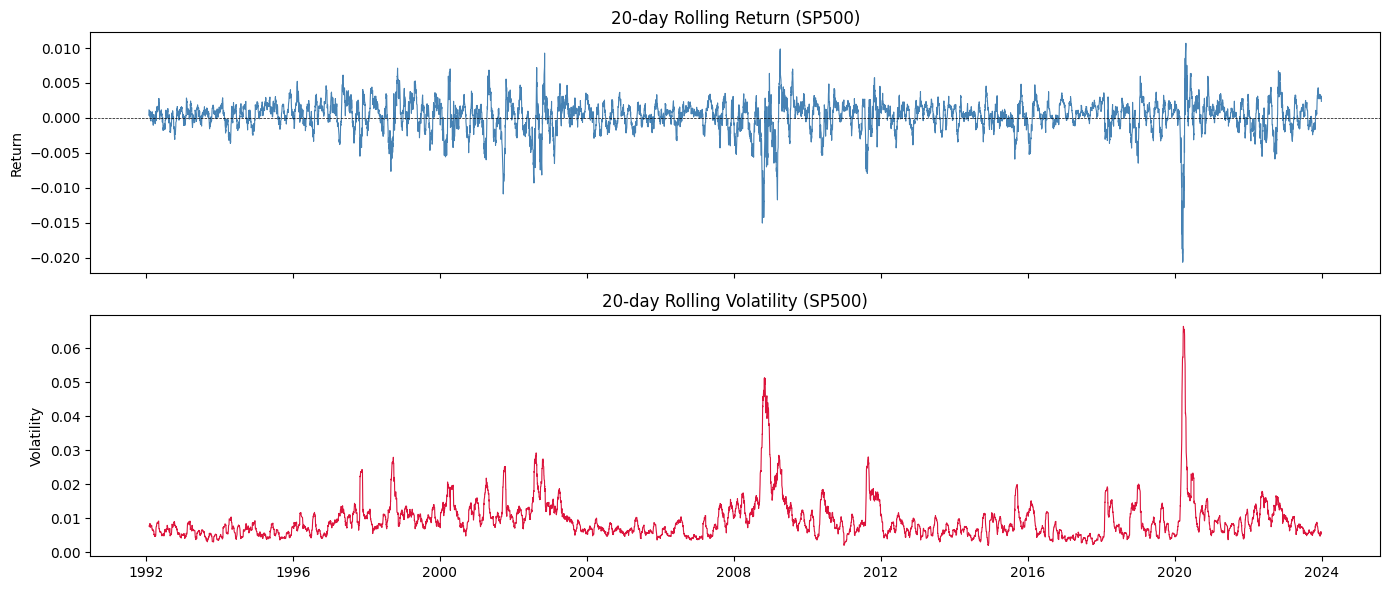

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(features.index, features['rolling_return'], color='steelblue', linewidth=0.8)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.set_title('20-day Rolling Return (SP500)')
ax1.set_ylabel('Return')

ax2.plot(features.index, features['rolling_vol'], color='crimson', linewidth=0.8)
ax2.set_title('20-day Rolling Volatility (SP500)')
ax2.set_ylabel('Volatility')

plt.tight_layout()
plt.show()

In [7]:
# split dates
train_end = '2005-12-31'
val_end   = '2014-12-31'

X_train = features[features.index <= train_end]
X_val   = features[(features.index > train_end) & (features.index <= val_end)]
X_test  = features[features.index > val_end]

print(f"Train: {X_train.shape[0]} days ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Val:   {X_val.shape[0]} days ({X_val.index[0].date()} to {X_val.index[-1].date()})")
print(f"Test:  {X_test.shape[0]} days ({X_test.index[0].date()} to {X_test.index[-1].date()})")

Train: 3510 days (1992-01-30 to 2005-12-30)
Val:   2265 days (2006-01-03 to 2014-12-31)
Test:  2264 days (2015-01-02 to 2023-12-29)


## Hidden Markov Model 
##### States
- State 0: calm market
- State 1: turbulent market

##### Emmissions
- 20 day rolling returns
- 20 day rolling volatility

##### Process
- Used the HMM Learn library & the Baum Welch Algorithm to Learn:
- The transition Probability Matrix
- The gaussian emission distributions for each hidden state
- The intitial state probabilities 


In [8]:
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

# scale features - HMM is sensitive to feature magnitudes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# fit HMM with 2 states (calm and turbulent)
model_hmm = hmm.GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)
model_hmm.fit(X_train_scaled)

# decode regimes on full dataset
X_all_scaled = scaler.transform(features)
hmm_regimes = model_hmm.predict(X_all_scaled)

# add to features dataframe
features['hmm_regime'] = hmm_regimes

print("Regime counts:")
print(features['hmm_regime'].value_counts())
print("\nTransition matrix:")
print(model_hmm.transmat_.round(4))

Regime counts:
hmm_regime
0    4890
1    3149
Name: count, dtype: int64

Transition matrix:
[[0.9914 0.0086]
 [0.013  0.987 ]]


In [9]:
print("State means (rolling_return, rolling_vol):")
print(model_hmm.means_.round(6))

print("\nInitial state probabilities:")
print(model_hmm.startprob_.round(4))

# get regime probabilities on full dataset
probs_all = model_hmm.predict_proba(X_all_scaled)

# add to features dataframe
features['hmm_p_state0'] = probs_all[:, 0]
features['hmm_p_state1'] = probs_all[:, 1]

print("\nSample probabilities:")
print(features[['hmm_regime', 'hmm_p_state0', 'hmm_p_state1']].head(10))

State means (rolling_return, rolling_vol):
[[ 0.131969 -0.60148 ]
 [-0.199867  0.910938]]

Initial state probabilities:
[1. 0.]
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

Sample probabilities:
            hmm_regime  hmm_p_state0  hmm_p_state1
Date                                              
1992-01-30           0      1.000000  1.507910e-50
1992-01-31           0      0.999988  1.243007e-05
1992-02-03           0      0.999985  1.464173e-05
1992-02-04           0      0.999977  2.334470e-05
1992-02-05           0      0.999974  2.629213e-05
1992-02-06           0      0.999972  2.785850e-05
1992-02-07           0      0.999963  3.658586e-05
1992-02-10           0      0.999964  3.553497e-05
1992-02-11           0      0.999987  1.303075e-05
1992-02-12           0      0.999987  1.250270e-05


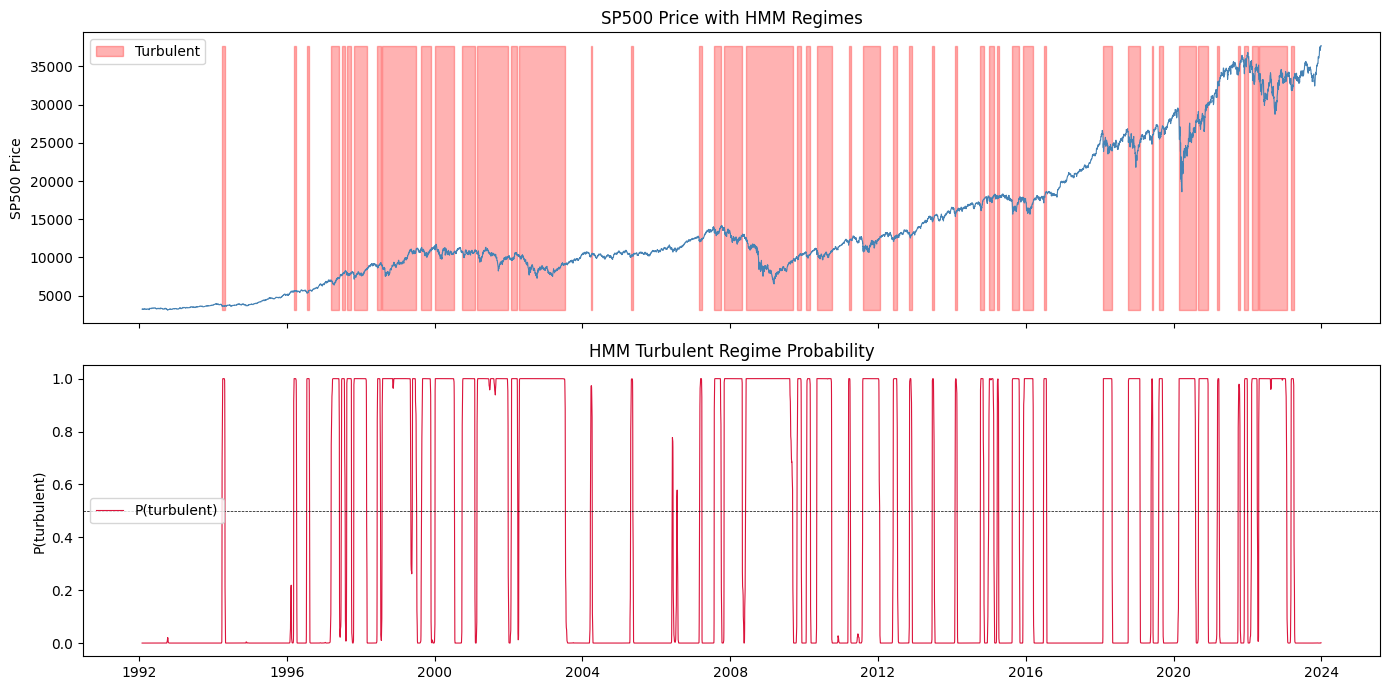

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# plot SP500 price level
sp500_price = raw['SP500'][features.index]
ax1.plot(features.index, sp500_price, color='steelblue', linewidth=0.8)
ax1.set_ylabel('SP500 Price')
ax1.set_title('SP500 Price with HMM Regimes')

# shade turbulent periods (state 1)
turbulent = features['hmm_regime'] == 1
ax1.fill_between(features.index, sp500_price.min(), sp500_price.max(),
                 where=turbulent, alpha=0.3, color='red', label='Turbulent')
ax1.legend()

# plot regime probabilities
ax2.plot(features.index, features['hmm_p_state1'], 
         color='crimson', linewidth=0.8, label='P(turbulent)')
ax2.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax2.set_ylabel('P(turbulent)')
ax2.set_title('HMM Turbulent Regime Probability')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
# count how many regime switches HMM makes
switches = (features['hmm_regime'].diff() != 0).sum()
print(f"Total regime switches: {switches}")
print(f"Average days between switches: {len(features) / switches:.1f}")

Total regime switches: 97
Average days between switches: 82.9


In [12]:
# align returns with features index
strat_returns = returns['SP500'][features.index].copy()

# calm = state 0, so invest when hmm_regime == 0
# use .shift(1) to avoid lookahead bias - today's regime signal
# determines tomorrow's position
features['hmm_position'] = (features['hmm_regime'] == 0).astype(int).shift(1)

# strategy return = position * market return
features['hmm_strat_return'] = features['hmm_position'] * strat_returns

# buy and hold for comparison
features['bh_return'] = strat_returns

print("Strategy return sample:")
print(features[['hmm_position', 'hmm_strat_return', 'bh_return']].head(10))

Strategy return sample:
            hmm_position  hmm_strat_return  bh_return
Date                                                 
1992-01-30           NaN               NaN   0.006152
1992-01-31           1.0         -0.006648  -0.006648
1992-02-03           1.0          0.003314   0.003314
1992-02-04           1.0          0.011895   0.011895
1992-02-05           1.0         -0.004655  -0.004655
1992-02-06           1.0         -0.000614  -0.000614
1992-02-07           1.0         -0.009320  -0.009320
1992-02-10           1.0          0.006089   0.006089
1992-02-11           1.0          0.002001   0.002001
1992-02-12           1.0          0.007720   0.007720


## Comparing the Buy and Hold Strategy vs HMM Binary model

### Buy and hold
- invest on day 1 and don't touch it again

### HMM Binary model 
- Calm regime (state 0): 100% invested in S&P 500
- Turbulent regime (state 1): 100% invested in cash, earning nothing

In [15]:
def evaluate_strategy(returns_series, label, rf=0.0):
    r = returns_series.dropna()
    total_return = r.sum()
    ann_return = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol
    
    # max drawdown
    cumulative = (1 + r).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    print(f"\n{label}")
    print(f"  Annualized Return : {ann_return:.4f}")
    print(f"  Annualized Vol    : {ann_vol:.4f}")
    print(f"  Sharpe Ratio      : {sharpe:.4f}")
    print(f"  Max Drawdown      : {max_dd:.4f}")

# evaluate on test set only
test_idx = features.index > val_end


In [16]:
# transaction cost per switch
tc = 0.001  # 0.1%

# detect switches - days where position changes
position = features['hmm_position'].fillna(0)
switches = (position.diff().abs() > 0).astype(int)

# subtract transaction cost on switch days
features['hmm_strat_return_tc'] = (
    features['hmm_strat_return'] - switches * tc
)

print(f"Total switches in full period: {switches.sum()}")
print(f"Total switches in test period: {switches[test_idx].sum()}")

# re-evaluate with transaction costs
evaluate_strategy(features.loc[test_idx, 'bh_return'], 'Buy and Hold')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return'], 'HMM Binary (no TC)')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return_tc'], 'HMM Binary (with TC)')

Total switches in full period: 97
Total switches in test period: 34

Buy and Hold
  Annualized Return : 0.0834
  Annualized Vol    : 0.1817
  Sharpe Ratio      : 0.4588
  Max Drawdown      : -0.3941

HMM Binary (no TC)
  Annualized Return : 0.0386
  Annualized Vol    : 0.0874
  Sharpe Ratio      : 0.4414
  Max Drawdown      : -0.1959

HMM Binary (with TC)
  Annualized Return : 0.0348
  Annualized Vol    : 0.0874
  Sharpe Ratio      : 0.3982
  Max Drawdown      : -0.2039


# Analysis
### Buy & Hold Strategy 
- decent returns, poor drawdown most likely due to 2020 pandemic

### HMM Binary (no TC) 
- drawdown cut in ~1/2
- less return, comparable sharpe ratio

### HMM Binary with TC
- Sharpe dropped considerably
- How was the transition cost implemented ?
  - Every time the strategy switches we subtract 0.1% from the return that day
  - What does the 0.1% represent?
     - Bid-ask spread: the price you buy at is slightly higher than the price you could immediately sell at
     - Market impact: trade slightly moves the price against you
     - Brokerage commissions
  - For modern index based trading, percentage based costs dominate commissions, which is why the transaction cost should scale with the position size



In [20]:
from jumpmodels.jump import JumpModel
print("jump model library loaded")

jump model library loaded


In [22]:
from jumpmodels.jump import JumpModel

# jump model needs clean scaled dataframes with no NaNs
# reuse the scaler we already fitted on X_train
X_train_jm = pd.DataFrame(
    scaler.transform(X_train), 
    index=X_train.index, 
    columns=X_train.columns
)

X_all_jm = pd.DataFrame(
    scaler.transform(features[['rolling_return', 'rolling_vol']]),
    index=features.index,
    columns=['rolling_return', 'rolling_vol']
)

# fit on training data only
jm = JumpModel(n_components=2, jump_penalty=50.0, cont=False)
jm.fit(X_train_jm, sort_by="cumret")

# predict on full dataset
jm_regimes = jm.predict(X_all_jm)
features['jm_regime'] = jm_regimes

# get probabilities
jm_probs = jm.predict_proba(X_all_jm)
features['jm_p_state0'] = jm_probs.iloc[:, 0]
features['jm_p_state1'] = jm_probs.iloc[:, 1]

print("Regime counts:")
print(features['jm_regime'].value_counts())

jm_switches = (features['jm_regime'].diff() != 0).sum()
print(f"\nTotal regime switches: {jm_switches}")
print(f"Average days between switches: {len(features) / jm_switches:.1f}")
print(f"\nHMM switches for comparison: 97, avg 82.9 days")

Regime counts:
jm_regime
0    4776
1    3263
Name: count, dtype: int64

Total regime switches: 17
Average days between switches: 472.9

HMM switches for comparison: 97, avg 82.9 days


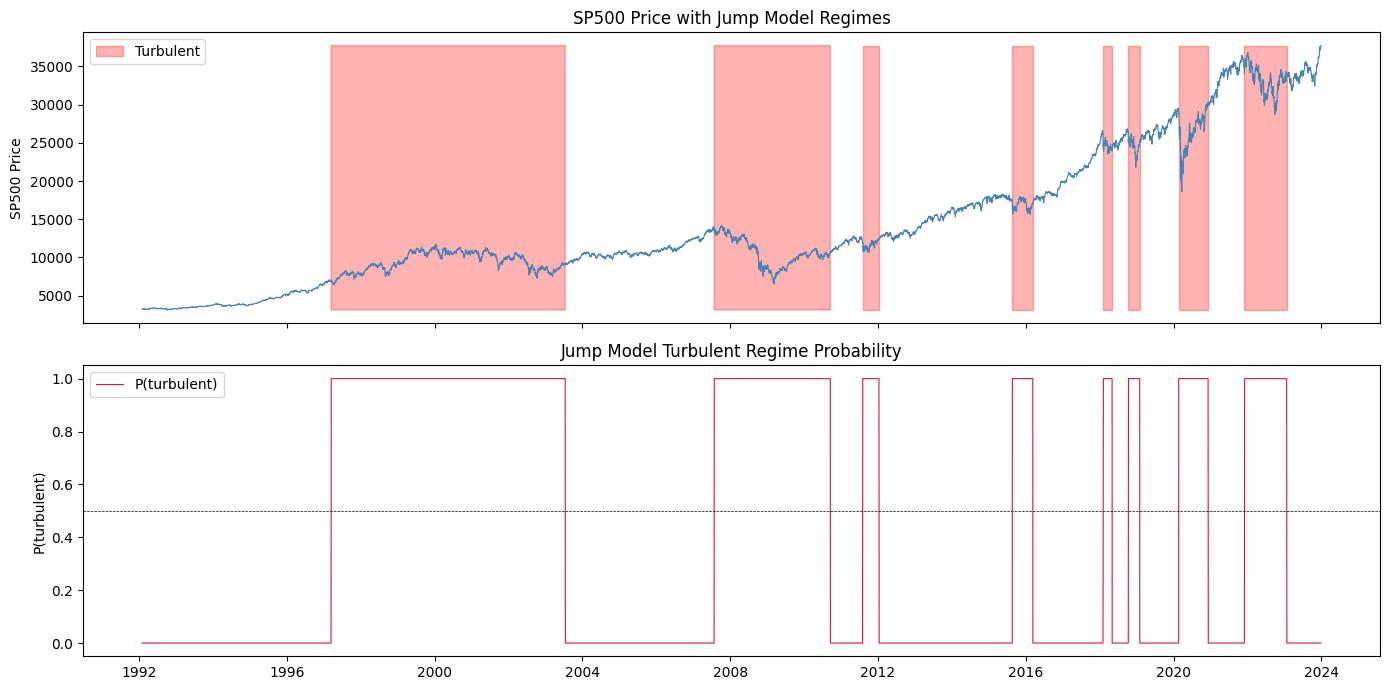

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

sp500_price = raw['SP500'][features.index]
ax1.plot(features.index, sp500_price, color='steelblue', linewidth=0.8)
ax1.set_ylabel('SP500 Price')
ax1.set_title('SP500 Price with Jump Model Regimes')

turbulent_jm = features['jm_regime'] == 1
ax1.fill_between(features.index, sp500_price.min(), sp500_price.max(),
                 where=turbulent_jm, alpha=0.3, color='red', label='Turbulent')
ax1.legend()

ax2.plot(features.index, features['jm_p_state1'],
         color='crimson', linewidth=0.8, label='P(turbulent)')
ax2.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax2.set_ylabel('P(turbulent)')
ax2.set_title('Jump Model Turbulent Regime Probability')
ax2.legend()

plt.tight_layout()
plt.show()

In [24]:
# jump model binary strategy - same logic as HMM
# state 0 = calm (sort_by cumret ensures this)
features['jm_position'] = (features['jm_regime'] == 0).astype(int).shift(1)
features['jm_strat_return'] = features['jm_position'] * strat_returns

# add transaction costs
jm_position = features['jm_position'].fillna(0)
jm_switches_ts = (jm_position.diff().abs() > 0).astype(int)
features['jm_strat_return_tc'] = features['jm_strat_return'] - jm_switches_ts * tc

# evaluate all strategies on test set
evaluate_strategy(features.loc[test_idx, 'bh_return'], 'Buy and Hold')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return_tc'], 'HMM Binary (with TC)')
evaluate_strategy(features.loc[test_idx, 'jm_strat_return_tc'], 'Jump Model Binary (with TC)')


Buy and Hold
  Annualized Return : 0.0834
  Annualized Vol    : 0.1817
  Sharpe Ratio      : 0.4588
  Max Drawdown      : -0.3941

HMM Binary (with TC)
  Annualized Return : 0.0348
  Annualized Vol    : 0.0874
  Sharpe Ratio      : 0.3982
  Max Drawdown      : -0.2039

Jump Model Binary (with TC)
  Annualized Return : 0.0761
  Annualized Vol    : 0.0905
  Sharpe Ratio      : 0.8406
  Max Drawdown      : -0.1109


In [27]:
# continuous jump model
jm_cont = JumpModel(n_components=2, jump_penalty=600.0, cont=True)
jm_cont.fit(X_train_jm, sort_by="cumret")

# get smooth probabilities
cjm_probs = jm_cont.predict_proba(X_all_jm)
features['cjm_p_state0'] = cjm_probs.iloc[:, 0]
features['cjm_p_state1'] = cjm_probs.iloc[:, 1]

# check that probabilities are actually smooth
print("Sample probabilities (should NOT be all 0s and 1s):")
print(features['cjm_p_state0'].describe())
print("\nUnique values sample:")
print(features['cjm_p_state0'].round(2).value_counts().head(10))

Sample probabilities (should NOT be all 0s and 1s):
count    8039.000000
mean        0.619978
std         0.477691
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: cjm_p_state0, dtype: float64

Unique values sample:
cjm_p_state0
1.00    4813
0.00    2884
0.90      18
0.40      18
0.05      18
0.10      18
0.15      18
0.20      18
0.25      18
0.30      18
Name: count, dtype: int64


In [29]:
# continuous position from CJM smooth probabilities
features['cjm_position'] = features['cjm_p_state0'].shift(1)
features['cjm_cont_return'] = features['cjm_position'] * strat_returns

# proportional transaction costs
cjm_pos = features['cjm_position'].fillna(0)
cjm_position_changes = cjm_pos.diff().abs()
features['cjm_cont_return_tc'] = features['cjm_cont_return'] - cjm_position_changes * tc

# full comparison
evaluate_strategy(features.loc[test_idx, 'bh_return'], 'Buy and Hold')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return_tc'], 'HMM Binary (with TC)')
evaluate_strategy(features.loc[test_idx, 'jm_strat_return_tc'], 'Jump Model Binary (with TC)')
evaluate_strategy(features.loc[test_idx, 'cjm_cont_return_tc'], 'CJM Continuous (with TC)')


Buy and Hold
  Annualized Return : 0.0834
  Annualized Vol    : 0.1817
  Sharpe Ratio      : 0.4588
  Max Drawdown      : -0.3941

HMM Binary (with TC)
  Annualized Return : 0.0348
  Annualized Vol    : 0.0874
  Sharpe Ratio      : 0.3982
  Max Drawdown      : -0.2039

Jump Model Binary (with TC)
  Annualized Return : 0.0761
  Annualized Vol    : 0.0905
  Sharpe Ratio      : 0.8406
  Max Drawdown      : -0.1109

CJM Continuous (with TC)
  Annualized Return : 0.0873
  Annualized Vol    : 0.0890
  Sharpe Ratio      : 0.9803
  Max Drawdown      : -0.1152


# Analysis
The binary strategy loses return every time it makes an abrupt switch — it goes fully to cash and misses some recovery days. The continuous strategy scales position down gradually during uncertain periods, stays partially invested, and therefore captures more of the upside without meaningfully increasing downside exposure.

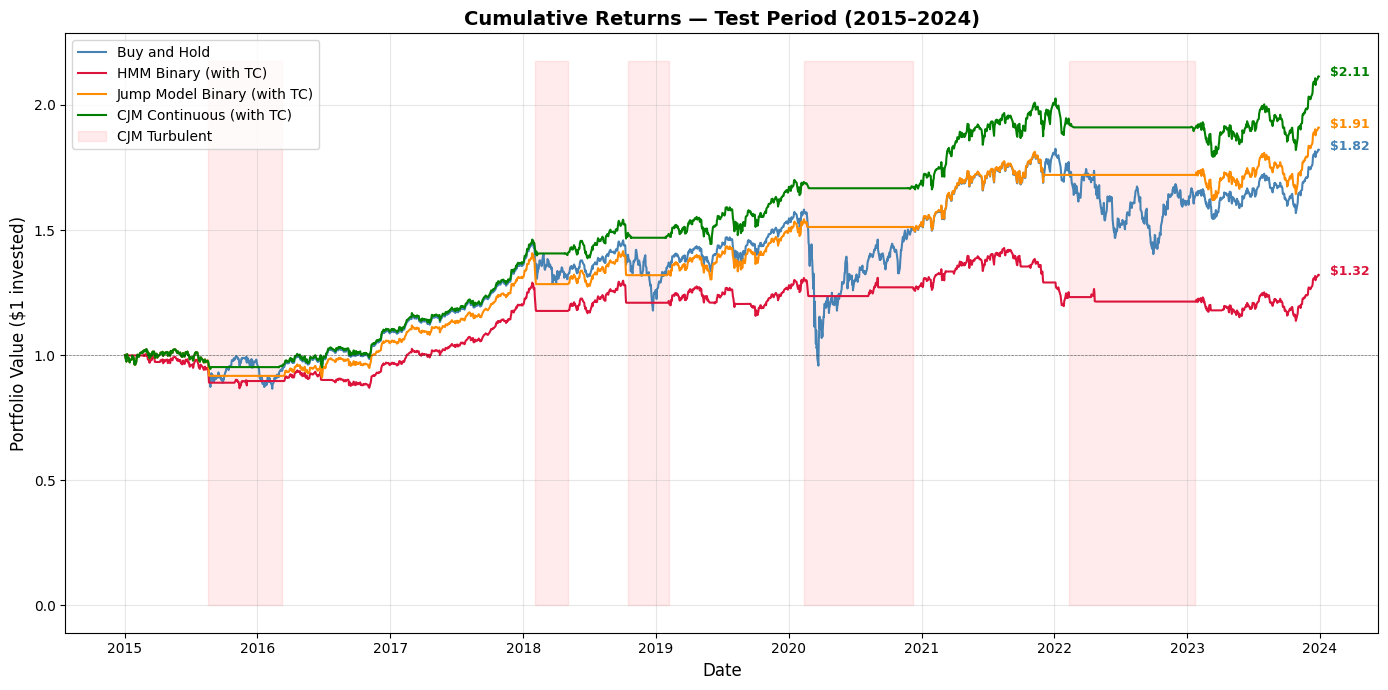


Final portfolio value ($1 invested in 2015):
  Buy and Hold: $1.82
  HMM Binary (with TC): $1.32
  Jump Model Binary (with TC): $1.91
  CJM Continuous (with TC): $2.11


In [30]:
fig, ax = plt.subplots(figsize=(14, 7))

# calculate cumulative returns for each strategy on full feature period
strategies = {
    'Buy and Hold':           'bh_return',
    'HMM Binary (with TC)':   'hmm_strat_return_tc',
    'Jump Model Binary (with TC)': 'jm_strat_return_tc',
    'CJM Continuous (with TC)':    'cjm_cont_return_tc',
}

colors = {
    'Buy and Hold':                'steelblue',
    'HMM Binary (with TC)':        'crimson',
    'Jump Model Binary (with TC)': 'darkorange',
    'CJM Continuous (with TC)':    'green',
}

# plot test period only
test_features = features.loc[test_idx]

for label, col in strategies.items():
    cumret = (1 + test_features[col].fillna(0)).cumprod()
    ax.plot(test_features.index, cumret, 
            label=label, color=colors[label], linewidth=1.5)

# shade drawdown periods using CJM turbulent regime
turbulent_test = test_features['cjm_p_state0'].shift(1).fillna(1) < 0.5
ax.fill_between(test_features.index, 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 3,
                where=turbulent_test, alpha=0.08, color='red', label='CJM Turbulent')

ax.set_title('Cumulative Returns — Test Period (2015–2024)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value ($1 invested)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(1.0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# add final value annotations
for label, col in strategies.items():
    cumret = (1 + test_features[col].fillna(0)).cumprod()
    final_val = cumret.iloc[-1]
    ax.annotate(f'${final_val:.2f}', 
                xy=(test_features.index[-1], final_val),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=colors[label], fontweight='bold')

plt.tight_layout()
plt.show()

# print final values clearly
print("\nFinal portfolio value ($1 invested in 2015):")
for label, col in strategies.items():
    cumret = (1 + test_features[col].fillna(0)).cumprod()
    print(f"  {label}: ${cumret.iloc[-1]:.2f}")

In [40]:
lambda_values = [10, 25, 50, 100, 200, 300, 500, 800, 1000]

val_returns = strat_returns[(strat_returns.index > train_end) & (strat_returns.index <= val_end)]

results = []

for lam in lambda_values:
    jm_lam = JumpModel(n_components=2, jump_penalty=lam, cont=True)
    jm_lam.fit(X_train_jm, sort_by="cumret")
    
    # build trainval block
    trainval_mask = features.index <= val_end
    X_trainval_jm = pd.DataFrame(
        scaler.transform(features.loc[trainval_mask, ['rolling_return', 'rolling_vol']]),
        index=features.index[trainval_mask],
        columns=['rolling_return', 'rolling_vol']
    )
    
    # get probs on trainval, then slice to val dates using loc
    probs = jm_lam.predict_proba(X_trainval_jm)
    p_calm_val = probs.iloc[:, 0].loc[val_returns.index]
    
    # build strategy
    position_val = p_calm_val.shift(1).fillna(0)
    strat_ret = position_val * val_returns
    pos_changes = position_val.diff().abs().fillna(0)
    strat_ret_tc = strat_ret - pos_changes * tc
    
    # sharpe on validation
    ann_ret = strat_ret_tc.mean() * 252
    ann_vol = strat_ret_tc.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    results.append({'lambda': lam, 'sharpe': sharpe, 'ann_return': ann_ret})
    print(f"λ = {lam:6.0f}  |  Sharpe = {sharpe:.4f}  |  Ann. Return = {ann_ret:.4f}")

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['sharpe'].idxmax()]
best_lambda = best_row['lambda']
print(f"\nBest λ = {best_lambda} with validation Sharpe = {best_row['sharpe']:.4f}")

λ =     10  |  Sharpe = 0.9036  |  Ann. Return = 0.0921
λ =     25  |  Sharpe = 0.9801  |  Ann. Return = 0.0992
λ =     50  |  Sharpe = 0.9817  |  Ann. Return = 0.0990
λ =    100  |  Sharpe = 0.9790  |  Ann. Return = 0.1044
λ =    200  |  Sharpe = 0.9611  |  Ann. Return = 0.1022
λ =    300  |  Sharpe = 0.9737  |  Ann. Return = 0.1027
λ =    500  |  Sharpe = 1.0641  |  Ann. Return = 0.0979
λ =    800  |  Sharpe = 0.9514  |  Ann. Return = 0.0797
λ =   1000  |  Sharpe = 0.9514  |  Ann. Return = 0.0797

Best λ = 500.0 with validation Sharpe = 1.0641
